In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
import kerastuner as kt
from keras.models import Sequential
from keras.layers import Dense, Dropout

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14176\1668405113.py:5: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [3]:
df = pd.read_csv(r'C:\Users\lenovo\OneDrive\Desktop\deep-learning\datasets\student_performance_dataset.csv')

In [4]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [6]:
df.isnull().sum()

Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

In [7]:
df = df.drop(['Student_ID', 'Gender'], axis=1)

In [8]:
df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,31,68.267841,86,High School,Yes,Yes,63,Pass
1,16,78.222927,73,PhD,No,No,50,Fail
2,21,87.525096,74,PhD,Yes,No,55,Fail
3,27,92.076483,99,Bachelors,No,No,65,Pass
4,37,98.655517,63,Masters,No,Yes,70,Pass


In [9]:
df['Pass_Fail'].unique()

array(['Pass', 'Fail'], dtype=object)

In [10]:
df['Pass_Fail'] = df['Pass_Fail'].str.strip().str.lower()

In [11]:
df['Pass_Fail'] = df['Pass_Fail'].map({'pass':1, 'fail':0})

In [12]:
df['Pass_Fail'].head()

0    1
1    0
2    0
3    1
4    1
Name: Pass_Fail, dtype: int64

In [13]:
string_col = [
    'Internet_Access_at_Home'
]

for col in string_col:
    df[col] = df[col].str.strip()

In [14]:
print(df['Internet_Access_at_Home'].unique())

['Yes' 'No']


In [15]:
df['Internet_Access_at_Home'] = (
    df['Internet_Access_at_Home']
    .str.strip()
    .str.lower()
    .map({'yes':1, 'no':0})
)

In [16]:
df['Internet_Access_at_Home'].head()

0    1
1    0
2    1
3    0
4    0
Name: Internet_Access_at_Home, dtype: int64

In [17]:
df['Extracurricular_Activities'].unique()

array(['Yes', 'No'], dtype=object)

In [18]:
df['Extracurricular_Activities'] = (
    df['Extracurricular_Activities']
    .str.strip()
    .str.lower()
    .map({'yes':1, 'no':0})
)

In [19]:
df['Extracurricular_Activities'].head()

0    1
1    0
2    0
3    0
4    1
Name: Extracurricular_Activities, dtype: int64

In [20]:
df["Parental_Education_Level"].unique()

array(['High School', 'PhD', 'Bachelors', 'Masters'], dtype=object)

In [21]:
eduction_map = {
    'High School' : 0,
    'Bachelors': 1,
    'Masters': 2,
    'PhD':3
}

df['Parental_Education_Level'] = df['Parental_Education_Level'].map(eduction_map)

In [22]:
df['Parental_Education_Level'].head()

0    0
1    3
2    3
3    1
4    2
Name: Parental_Education_Level, dtype: int64

In [23]:
df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,31,68.267841,86,0,1,1,63,1
1,16,78.222927,73,3,0,0,50,0
2,21,87.525096,74,3,1,0,55,0
3,27,92.076483,99,1,0,0,65,1
4,37,98.655517,63,2,0,1,70,1


In [24]:
X = df.drop('Pass_Fail', axis=1)
y = df['Pass_Fail'].values

In [25]:
X.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score
0,31,68.267841,86,0,1,1,63
1,16,78.222927,73,3,0,0,50
2,21,87.525096,74,3,1,0,55
3,27,92.076483,99,1,0,0,65
4,37,98.655517,63,2,0,1,70


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    random_state=42,
    test_size=0.2 
)

In [27]:
num_cols = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Past_Exam_Scores"
]

In [28]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [29]:
X_train

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score
522,1.296315,0.114690,1.122083,0,0,0,63
24,-0.737387,0.811106,0.984243,1,1,1,62
480,0.957365,-0.262167,0.708562,3,1,0,69
314,-1.528271,1.276705,-1.496882,1,0,1,60
239,1.409299,-1.165231,1.397763,1,1,0,63
...,...,...,...,...,...,...,...
71,0.957365,-1.348817,-1.565802,3,0,0,57
106,-1.528271,0.046697,-1.772562,2,0,1,50
270,0.957365,-1.258908,1.053163,1,0,0,63
435,0.844381,-0.327245,-1.083361,2,0,1,55


In [30]:
df.corr()['Pass_Fail']

Study_Hours_per_Week          0.296769
Attendance_Rate               0.396283
Past_Exam_Scores              0.436607
Parental_Education_Level      0.005093
Internet_Access_at_Home      -0.053829
Extracurricular_Activities    0.104540
Final_Exam_Score              0.864175
Pass_Fail                     1.000000
Name: Pass_Fail, dtype: float64

## Normal ANN model

In [31]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=7))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                256       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 289
Trainable params: 289
Non-trainable params: 0
_________________________________________________________________


In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test)
)

Epoch 1/50
18/18 [==============================] - 2s 17ms/step - loss: 1.2629 - accuracy: 0.4929 - val_loss: 0.8608 - val_accuracy: 0.5070
Epoch 2/50
18/18 [==============================] - 0s 8ms/step - loss: 0.7211 - accuracy: 0.5901 - val_loss: 0.6420 - val_accuracy: 0.6761
Epoch 3/50
18/18 [==============================] - 0s 9ms/step - loss: 0.6180 - accuracy: 0.6484 - val_loss: 0.5923 - val_accuracy: 0.6338
Epoch 4/50
18/18 [==============================] - 0s 7ms/step - loss: 0.5813 - accuracy: 0.6943 - val_loss: 0.5560 - val_accuracy: 0.7254
Epoch 5/50
18/18 [==============================] - 0s 6ms/step - loss: 0.5596 - accuracy: 0.7456 - val_loss: 0.5339 - val_accuracy: 0.7394
Epoch 6/50
18/18 [==============================] - 0s 7ms/step - loss: 0.5364 - accuracy: 0.7615 - val_loss: 0.5089 - val_accuracy: 0.7606
Epoch 7/50
18/18 [==============================] - 0s 7ms/step - loss: 0.5204 - accuracy: 0.7721 - val_loss: 0.4887 - val_accuracy: 0.8028
Epoch 8/50
18/18 [=

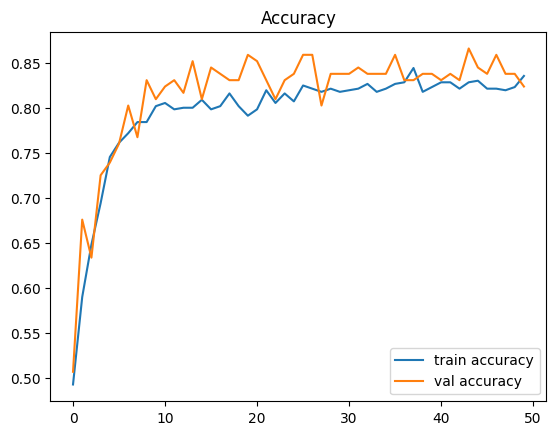

In [34]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

## Hyper Tunning the ANNs model

In [35]:
def build_model(hp):
    model = Sequential()

    num_layers = hp.Int('num_layers', min_value=1, max_value=5)

    for i in range(num_layers):
        units = hp.Int(f'units: {i}', min_value=8, max_value=128, step=8)
        activation = hp.Choice(f'acivation: {i}', ['relu', 'tanh', 'sigmoid'])
        dropout = hp.Float(f'dropout: {i}', min_value=0.1, max_value=0.7, step=0.1)

        if i == 0:
            model.add(Dense(units, activation=activation, input_dim=7))
        else:
            model.add(Dense(units, activation=activation))

        model.add(Dropout(dropout))

    model.add(Dense(1, activation='sigmoid'))
    optimizer = hp.Choice('optimizer', ['rmsprop', 'adam', 'sgd', 'adadelta', 'nadam'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    ) 
    return model


In [36]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=15,
    directory='Binary-Class-Hyper-Model',
    project_name='Model 1'
)

In [37]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Trial 15 Complete [00h 00m 02s]
val_accuracy: 0.5

Best val_accuracy So Far: 0.8450704216957092
Total elapsed time: 00h 00m 28s


In [38]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 2,
 'units: 0': 64,
 'acivation: 0': 'tanh',
 'dropout: 0': 0.1,
 'optimizer': 'rmsprop',
 'units: 1': 72,
 'acivation: 1': 'tanh',
 'dropout: 1': 0.4,
 'units: 2': 48,
 'acivation: 2': 'sigmoid',
 'dropout: 2': 0.6,
 'units: 3': 72,
 'acivation: 3': 'relu',
 'dropout: 3': 0.1,
 'units: 4': 16,
 'acivation: 4': 'tanh',
 'dropout: 4': 0.4}

In [39]:
model = tuner.get_best_models(num_models=1)[0]

In [40]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    initial_epoch=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 6/50
18/18 [==============================] - 1s 16ms/step - loss: 0.5700 - accuracy: 0.7208 - val_loss: 0.5244 - val_accuracy: 0.7254
Epoch 7/50
18/18 [==============================] - 0s 9ms/step - loss: 0.5207 - accuracy: 0.7580 - val_loss: 0.4246 - val_accuracy: 0.8239
Epoch 8/50
18/18 [==============================] - 0s 9ms/step - loss: 0.4805 - accuracy: 0.7845 - val_loss: 0.3939 - val_accuracy: 0.8239
Epoch 9/50
18/18 [==============================] - 0s 8ms/step - loss: 0.4590 - accuracy: 0.7827 - val_loss: 0.4662 - val_accuracy: 0.7887
Epoch 10/50
18/18 [==============================] - 0s 9ms/step - loss: 0.4603 - accuracy: 0.7756 - val_loss: 0.3619 - val_accuracy: 0.8521
Epoch 11/50
18/18 [==============================] - 0s 9ms/step - loss: 0.4162 - accuracy: 0.8074 - val_loss: 0.3388 - val_accuracy: 0.8310
Epoch 12/50
18/18 [==============================] - 0s 9ms/step - loss: 0.3983 - accuracy: 0.8127 - val_loss: 0.3729 - val_accuracy: 0.8521
Epoch 13/50
18/1

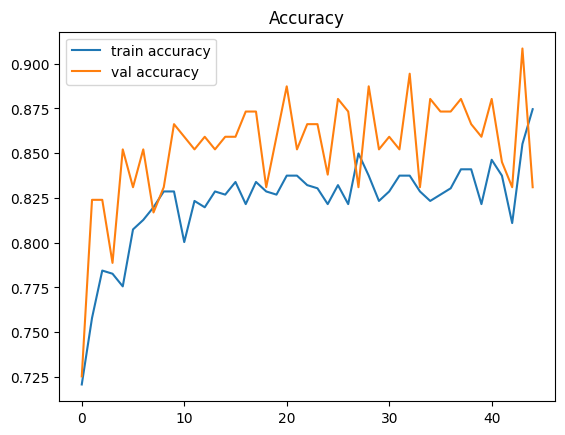

In [41]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

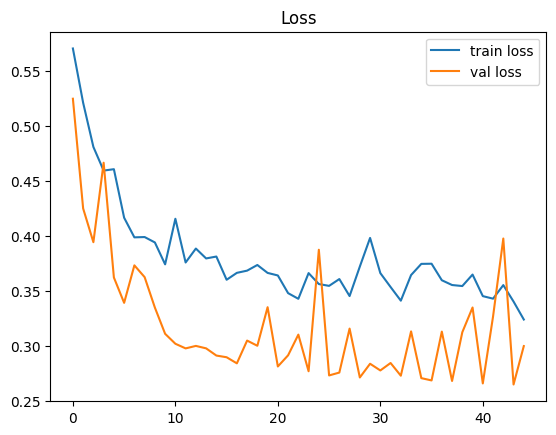

In [42]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()